# AWP Wind Lidar Planning

**Purpose:** This notebook demonstrates how to plan flights for NASA Langley's Aerosol Wind Profiler (AWP) using HyPlan. AWP is not a swath-mapping instrument like an imaging spectrometer or SAR; instead, it alternates between two off-nadir lines of sight (LOS) to derive horizontal wind-vector profiles along the flight path. That means AWP planning is driven by stable straight-and-level legs, LOS geometry, and vector-profile spacing.

The geometry and operating assumptions used here follow Bedka et al. (2024) and Bedka (2025), which are cited in the references section at the end of the notebook.

| | |
|---|---|
| **Audience** | Intermediate |
| **Runtime** | < 2 minutes |
| **Requires internet** | Optional (terrain-aware section downloads DEM) |
| **Credentials required** | None |
| **Optional dependencies** | None |
| **Uses example data** | No |

**What You Will Learn:**
- How the AWP instrument model represents dual-LOS wind-lidar geometry
- How vector-profile spacing depends on dwell time and aircraft speed
- How to predict where AWP profiles fall along a flight line
- How terrain changes AGL and LOS intercept placement along a mountainous leg
- How wind-driven crab angle rotates the AWP LOS geometry along a full plan
- How to flag which parts of a full flight plan are stable enough for AWP retrievals


In [1]:
import datetime as dt

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from hyplan import (
    AerosolWindProfiler,
    ConstantWindField,
    FlightLine,
    NASA_GIII,
    awp_profile_locations_for_flight_line,
    awp_profile_locations_for_plan,
    compute_flight_plan,
    flag_awp_stable_segments,
    racetrack,
    ureg,
)

from hyplan.terrain import generate_demfile


def plot_awp_los(ax, profiles, *, every=8, los1_color="#16a34a", los2_color="#dc2626", alpha=0.22, linewidth=0.8):
    """Draw sampled LOS beam segments from platform to intercepts."""
    subset = profiles.iloc[::every]
    for _, row in subset.iterrows():
        if np.isfinite(row.get("los1_lon", np.nan)) and np.isfinite(row.get("los1_lat", np.nan)):
            ax.plot(
                [row["platform_lon"], row["los1_lon"]],
                [row["platform_lat"], row["los1_lat"]],
                color=los1_color,
                alpha=alpha,
                linewidth=linewidth,
            )
        if np.isfinite(row.get("los2_lon", np.nan)) and np.isfinite(row.get("los2_lat", np.nan)):
            ax.plot(
                [row["platform_lon"], row["los2_lon"]],
                [row["platform_lat"], row["los2_lat"]],
                color=los2_color,
                alpha=alpha,
                linewidth=linewidth,
            )

## 1. AWP Instrument Overview

The HyPlan `AerosolWindProfiler` class is a planning-oriented model derived from Bedka et al. (2024) and the Bedka (2025) NOAA 3-D winds final report. It captures the geometry and timing assumptions that matter for flight design:

- **Dual LOS:** two viewing directions at `±45°` azimuth from the aircraft nose
- **Off-nadir angle:** `30°`
- **Common airborne mode:** `3 s` on LOS1, `1 s` nadir, `3 s` on LOS2
- **Nominal speed:** `225 m/s`, giving vector profiles every `~1.6 km`
- **Planning constraint:** useful wind-vector retrievals require stable flight; turns and strong altitude changes create gaps

This means AWP belongs in a different planning category than conventional swath sensors. The key questions are not "what width do I map?" but "where do my wind profiles land, and which legs are actually usable?"


In [2]:
awp = AerosolWindProfiler()

summary = pd.DataFrame(
    [
        ("Wavelength", f"{awp.wavelength:.2f}"),
        ("Off-nadir angle", f"{awp.off_nadir_angle:.1f} deg"),
        ("Relative LOS azimuths", f"{awp.los_azimuths_relative[0]:.0f}°, {awp.los_azimuths_relative[1]:.0f}°"),
        ("Pulse rate", f"{awp.pulse_rate:.0f}"),
        ("Max slant range", f"{awp.max_slant_range().to(ureg.kilometer):.1f}"),
        ("Max vertical range", f"{awp.max_vertical_range().to(ureg.kilometer):.1f}"),
        ("Blind zone", f"{awp.blind_zone:.0f}"),
        ("Vector profile spacing @ 225 m/s", f"{awp.vector_profile_spacing(225 * ureg.meter / ureg.second).to(ureg.kilometer):.2f}"),
        ("LOS separation @ 12 km AGL", f"{awp.los_surface_separation(12 * ureg.kilometer).to(ureg.kilometer):.2f}"),
        ("Vertical bin spacing (256 FFT samples)", f"{awp.vertical_bin_spacing(256).to(ureg.meter):.1f}"),
        ("Vertical bin spacing (512 FFT samples)", f"{awp.vertical_bin_spacing(512).to(ureg.meter):.1f}"),
    ],
    columns=["Parameter", "Value"],
)

summary


,Parameter,Value
0,Wavelength,2052.92 nanometer
1,Off-nadir angle,30.0 deg
2,Relative LOS azimuths,"-45°, 45°"
3,Pulse rate,200 hertz
4,Max slant range,19.6 kilometer
5,Max vertical range,17.0 kilometer
6,Blind zone,200 meter
7,Vector profile spacing @ 225 m/s,1.57 kilometer
8,LOS separation @ 12 km AGL,9.80 kilometer
9,Vertical bin spacing (256 FFT samples),66.5 meter


## 2. Profile Locations Along a Single Flight Line

For a single straight survey leg, HyPlan can place the expected AWP vector profiles along the flight path and compute the two LOS ground intercepts associated with each sample location.

Below we make a simple northbound `80 km` line at `12 km` altitude and ask where AWP would place vector profiles if the aircraft were cruising at `225 m/s`.


In [3]:
flight_line = FlightLine.start_length_azimuth(
    lat1=34.0,
    lon1=-118.2,
    length=80 * ureg.kilometer,
    az=0.0,
    altitude_msl=12 * ureg.kilometer,
    site_name="AWP Example Leg",
)

profiles = awp_profile_locations_for_flight_line(
    flight_line,
    ground_speed=225 * ureg.meter / ureg.second,
    start_time=dt.datetime(2025, 10, 15, 17, 0, 0),
    altitude_agl=12 * ureg.kilometer,
)

profiles[[
    "sample_index",
    "distance_from_start_m",
    "elapsed_time_s",
    "time_utc",
    "platform_heading_deg",
    "los_surface_separation_m",
]].head(8)


,sample_index,distance_from_start_m,elapsed_time_s,time_utc,platform_heading_deg,los_surface_separation_m
0,1,900.0,4.0,2025-10-15 17:00:04,0.0,9797.958971
1,2,2475.0,11.0,2025-10-15 17:00:11,0.0,9797.958971
2,3,4050.0,18.0,2025-10-15 17:00:18,0.0,9797.958971
3,4,5625.0,25.0,2025-10-15 17:00:25,0.0,9797.958971
4,5,7200.0,32.0,2025-10-15 17:00:32,0.0,9797.958971
5,6,8775.0,39.0,2025-10-15 17:00:39,0.0,9797.958971
6,7,10350.0,46.0,2025-10-15 17:00:46,0.0,9797.958971
7,8,11925.0,53.0,2025-10-15 17:00:53,0.0,9797.958971


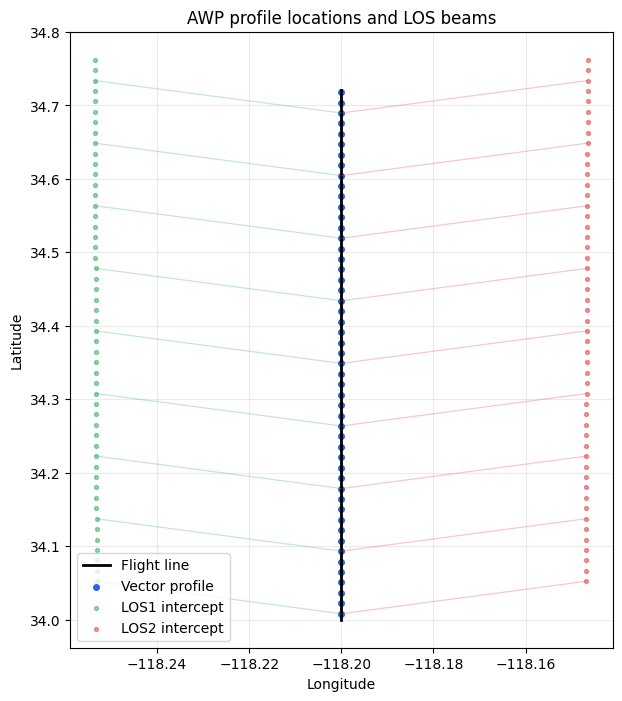

In [4]:
fig, ax = plt.subplots(figsize=(7, 8))

ax.plot([flight_line.lon1, flight_line.lon2], [flight_line.lat1, flight_line.lat2], color="black", linewidth=2, label="Flight line")
plot_awp_los(ax, profiles, every=6, alpha=0.25, linewidth=0.9)
ax.scatter(profiles["platform_lon"], profiles["platform_lat"], s=16, color="#2563eb", label="Vector profile")
ax.scatter(profiles["los1_lon"], profiles["los1_lat"], s=8, alpha=0.45, color="#16a34a", label="LOS1 intercept")
ax.scatter(profiles["los2_lon"], profiles["los2_lat"], s=8, alpha=0.45, color="#dc2626", label="LOS2 intercept")

ax.set_title("AWP profile locations and LOS beams")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(loc="best")
ax.grid(alpha=0.25)
plt.show()

## 3. Terrain-Aware LOS Placement

A fixed flight altitude MSL does **not** imply a fixed AGL over mountains. In `terrain_aware` mode, HyPlan samples terrain beneath each planned profile location, computes the local AGL, and ray-traces both AWP beams into a DEM to estimate terrain-adjusted LOS intercepts.

This example uses a line across the San Gabriel Mountains. The DEM is downloaded on first run and then reused from the local cache.


In [5]:
mountain_line = FlightLine.start_length_azimuth(
    lat1=34.15,
    lon1=-118.05,
    length=55 * ureg.kilometer,
    az=45.0,
    altitude_msl=6.5 * ureg.kilometer,
    site_name="San Gabriel Terrain Leg",
)

terrain_dem = generate_demfile(
    np.array([mountain_line.lat1, mountain_line.lat2]),
    np.array([mountain_line.lon1, mountain_line.lon2]),
)

terrain_profiles = awp_profile_locations_for_flight_line(
    mountain_line,
    ground_speed=225 * ureg.meter / ureg.second,
    start_time=dt.datetime(2025, 10, 15, 18, 0, 0),
    terrain_aware=True,
    dem_file=terrain_dem,
)

terrain_profiles[[
    "sample_index",
    "terrain_elevation_m",
    "altitude_agl_m",
    "los_surface_separation_m",
    "los1_alt_m",
    "los2_alt_m",
]].head(8)


,sample_index,terrain_elevation_m,altitude_agl_m,los_surface_separation_m,los1_alt_m,los2_alt_m
0,1,197.074249,6302.925751,4946.896050,709.660828,194.199783
1,2,229.623642,6270.376358,4851.920890,862.870544,292.417206
2,3,257.109039,6242.890961,4846.892504,623.345459,536.514404
3,4,887.710449,5612.289551,4677.921810,906.524841,679.590149
4,5,1001.766602,5498.233398,4414.092692,1315.075928,937.372864
5,6,1412.078247,5087.921753,4655.727087,814.247498,801.863770
6,7,1543.118530,4956.881470,4529.848651,819.756226,1107.310425
7,8,1086.956787,5413.043213,4465.679931,942.098938,1163.007935


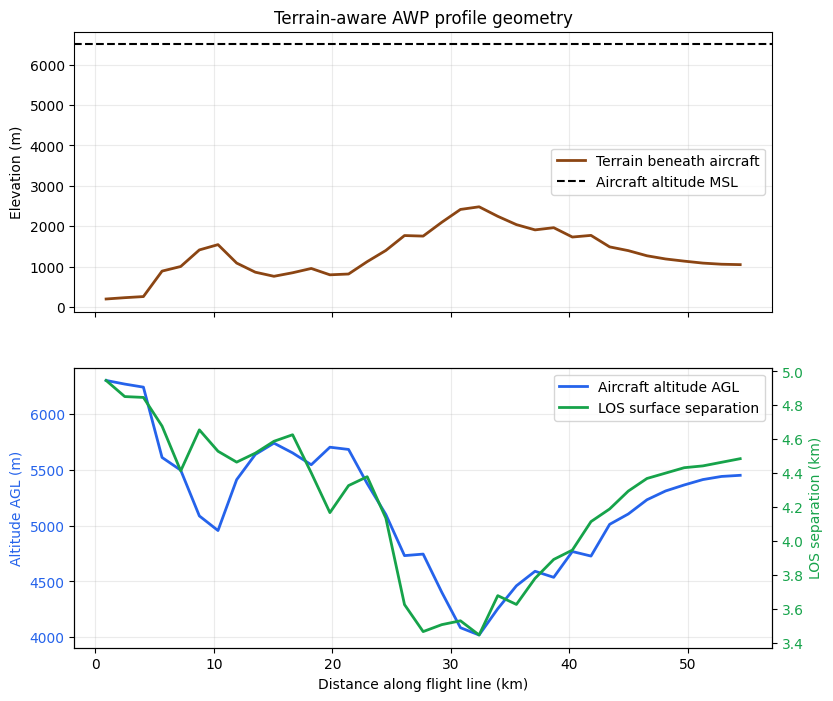

In [6]:
distance_km = terrain_profiles["distance_from_start_m"] / 1000.0
flight_altitude_m = mountain_line.altitude_msl.to("meter").magnitude

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

ax1.plot(distance_km, terrain_profiles["terrain_elevation_m"], color="saddlebrown", linewidth=2, label="Terrain beneath aircraft")
ax1.axhline(flight_altitude_m, color="black", linestyle="--", linewidth=1.5, label="Aircraft altitude MSL")
ax1.set_ylabel("Elevation (m)")
ax1.set_title("Terrain-aware AWP profile geometry")
ax1.grid(alpha=0.25)
ax1.legend(loc="best")

ax2.plot(distance_km, terrain_profiles["altitude_agl_m"], color="#2563eb", linewidth=2, label="Aircraft altitude AGL")
ax2.set_xlabel("Distance along flight line (km)")
ax2.set_ylabel("Altitude AGL (m)", color="#2563eb")
ax2.tick_params(axis="y", labelcolor="#2563eb")
ax2.grid(alpha=0.25)

ax2b = ax2.twinx()
ax2b.plot(distance_km, terrain_profiles["los_surface_separation_m"] / 1000.0, color="#16a34a", linewidth=2, label="LOS surface separation")
ax2b.set_ylabel("LOS separation (km)", color="#16a34a")
ax2b.tick_params(axis="y", labelcolor="#16a34a")

lines = ax2.get_lines() + ax2b.get_lines()
labels = [line.get_label() for line in lines]
ax2.legend(lines, labels, loc="best")
plt.show()


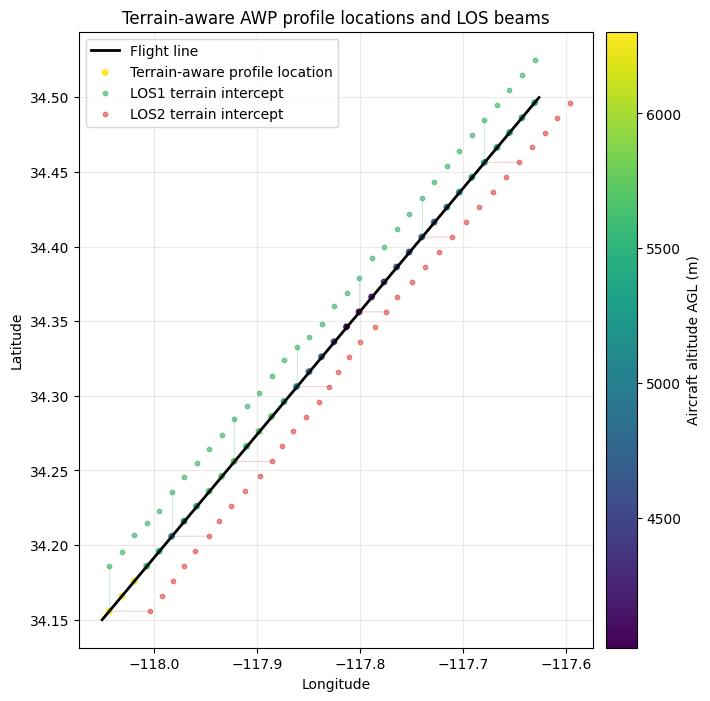

In [7]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(
    [mountain_line.lon1, mountain_line.lon2],
    [mountain_line.lat1, mountain_line.lat2],
    color="black",
    linewidth=2,
    label="Flight line",
)

plot_awp_los(ax, terrain_profiles, every=5, alpha=0.2, linewidth=0.85)

sc = ax.scatter(
    terrain_profiles["platform_lon"],
    terrain_profiles["platform_lat"],
    c=terrain_profiles["altitude_agl_m"],
    cmap="viridis",
    s=28,
    edgecolor="white",
    linewidth=0.4,
    label="Terrain-aware profile location",
)

ax.scatter(
    terrain_profiles["los1_lon"],
    terrain_profiles["los1_lat"],
    s=10,
    alpha=0.5,
    color="#16a34a",
    label="LOS1 terrain intercept",
)
ax.scatter(
    terrain_profiles["los2_lon"],
    terrain_profiles["los2_lat"],
    s=10,
    alpha=0.5,
    color="#dc2626",
    label="LOS2 terrain intercept",
)

cbar = plt.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label("Aircraft altitude AGL (m)")

ax.set_title("Terrain-aware AWP profile locations and LOS beams")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(alpha=0.25)
ax.legend(loc="best")
plt.show()

**What changed here?** Terrain raises and lowers the effective AGL even though the aircraft stays at a fixed `6.5 km` MSL. Because the terrain-aware mode ray-traces each LOS into the DEM, the surface intercept separation also varies along the leg instead of staying fixed at a flat-earth value. The LOS beam overlays make that geometry visible directly, not just through the intercept points. That makes this mode a better planning approximation for mountainous wind-profiling sorties.


## 4. Dwell-Time Sensitivity

AWP planning has a strong tradeoff between **horizontal resolution** and **signal integration**. Longer dwell per LOS improves sensitivity, but pushes vector profiles farther apart.

This is a natural planning parameter to explore in HyPlan because it directly changes the spacing of expected profile locations.


In [8]:
rows = []
for dwell_s in [2, 3, 6, 15]:
    dwell = dwell_s * ureg.second
    rows.append(
        {
            "Dwell per LOS (s)": dwell_s,
            "Pulses per LOS": int((awp.pulse_rate * dwell).to_base_units().magnitude),
            "Time between vector profiles (s)": awp.vector_profile_time_spacing(
                dwell_time_per_los=dwell,
                nadir_dwell_time=1 * ureg.second,
            ).m_as("second"),
            "Distance between vector profiles (km)": awp.vector_profile_spacing(
                225 * ureg.meter / ureg.second,
                dwell_time_per_los=dwell,
                nadir_dwell_time=1 * ureg.second,
            ).m_as("kilometer"),
            "Distance to first profile (km)": awp.profile_assignment_offset(
                225 * ureg.meter / ureg.second,
                dwell_time_per_los=dwell,
                nadir_dwell_time=1 * ureg.second,
            ).m_as("kilometer"),
        }
    )

pd.DataFrame(rows)


,Dwell per LOS (s),Pulses per LOS,Time between vector profiles (s),Distance between vector profiles (km),Distance to first profile (km)
0,2,400,5.0,1.125,0.675
1,3,600,7.0,1.575,0.900
2,6,1200,13.0,2.925,1.575
3,15,3000,31.0,6.975,3.600


## 5. AWP Along a Multi-Leg Flight Plan

The more useful planning mode is to ask: **Which segments of a full sortie are stable enough for AWP to retrieve vector winds, and where would the profiles appear?**

The AWP helper functions treat turns, climbs, descents, and segments with strong heading or altitude changes as unstable. This mirrors the operational reality described in the report: the best AWP data comes from long, straight, stable legs.


In [9]:
pattern = racetrack(
    center=(34.1, -118.2),
    heading=90.0,
    altitude=12 * ureg.kilometer,
    leg_length=70 * ureg.kilometer,
    n_legs=4,
    offset=12 * ureg.kilometer,
)

plan = compute_flight_plan(
    aircraft=NASA_GIII(),
    flight_sequence=[pattern],
)

flagged = flag_awp_stable_segments(plan)
flagged[[
    "segment_type",
    "segment_name",
    "distance",
    "time_to_segment",
    "awp_heading_change_deg",
    "awp_altitude_change_m",
    "awp_stable_platform_ok",
]].head(12)


,segment_type,segment_name,distance,time_to_segment,awp_heading_change_deg,awp_altitude_change_m,awp_stable_platform_ok
0,flight_line,Leg1,43.797009,5.998129,0.495810,0.0,True
1,transit,Departure,25.769581,3.529220,178.723526,0.0,False
2,flight_line,Leg2,43.796982,5.998125,0.493803,0.0,True
3,transit,Leg2 to Leg3,25.873629,3.543469,179.479389,0.0,False
4,flight_line,Leg3,43.797006,5.998128,0.491802,0.0,True
5,transit,Leg3 to Leg4,25.769671,3.529232,178.751237,0.0,False
6,flight_line,Leg4,43.796982,5.998125,0.489805,0.0,True


In [10]:
profiles_plan = awp_profile_locations_for_plan(
    plan,
    takeoff_time=dt.datetime(2025, 10, 15, 17, 0, 0),
)

profiles_plan.groupby(["source_segment_type", "source_segment_name"]).size().rename("n_profiles")


source_segment_type  source_segment_name
flight_line          Leg1                   51
                     Leg2                   51
                     Leg3                   51
                     Leg4                   51
Name: n_profiles, dtype: int64

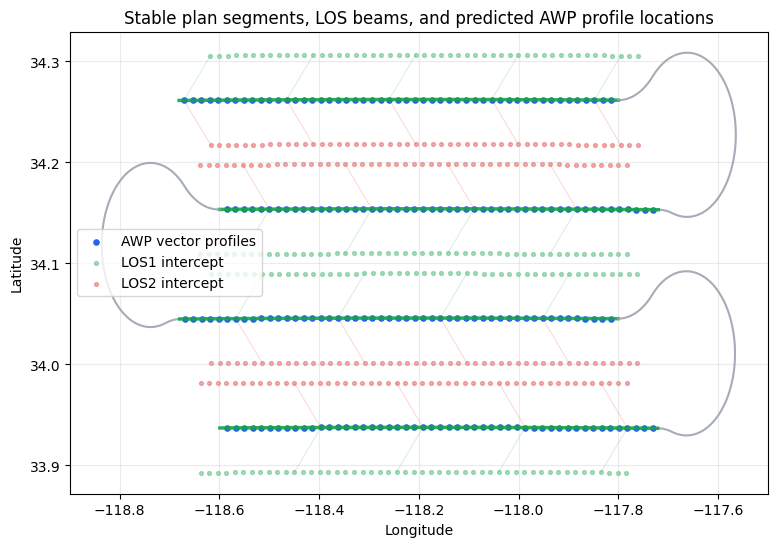

In [11]:
fig, ax = plt.subplots(figsize=(9, 6))

for _, row in flagged.iterrows():
    geom = row.geometry
    if getattr(geom, "geom_type", None) != "LineString":
        continue
    xs, ys = geom.xy
    color = "#16a34a" if row["awp_stable_platform_ok"] else "#9ca3af"
    width = 2.5 if row["segment_type"] == "flight_line" else 1.5
    ax.plot(xs, ys, color=color, linewidth=width, alpha=0.9)

plot_awp_los(ax, profiles_plan, every=12, alpha=0.18, linewidth=0.7)
ax.scatter(
    profiles_plan.geometry.x,
    profiles_plan.geometry.y,
    s=14,
    color="#2563eb",
    label="AWP vector profiles",
)
ax.scatter(
    profiles_plan["los1_lon"],
    profiles_plan["los1_lat"],
    s=8,
    color="#16a34a",
    alpha=0.35,
    label="LOS1 intercept",
)
ax.scatter(
    profiles_plan["los2_lon"],
    profiles_plan["los2_lat"],
    s=8,
    color="#dc2626",
    alpha=0.35,
    label="LOS2 intercept",
)

ax.set_title("Stable plan segments, LOS beams, and predicted AWP profile locations")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(alpha=0.25)
ax.legend(loc="best")
plt.show()

## 6. Wind- and Terrain-Aware Profiles Along a Flight Plan

For a full sortie, the interesting case is not just whether a leg is stable enough for AWP, but whether the aircraft must **crab into the wind** while holding the desired ground track. With `wind_aware=True`, `awp_profile_locations_for_plan` uses the plan's crab-angle metadata so the platform heading and the dual LOS azimuths follow the aircraft nose rather than the ground track. Adding `terrain_aware=True` at the same time ray-traces those crabbed LOS beams into terrain, which is the closest AWP analogue to crab-aware swath generation.

To keep this notebook responsive, the wind-aware demo below uses a **smaller two-leg racetrack** and precomputes a DEM once for the stable flight-line geometry before sampling AWP profiles.

In [18]:
from hyplan import ConstantWindField, NASA_GIII, awp_profile_locations_for_plan, compute_flight_plan, racetrack, ureg
import datetime as dt
import numpy as np

wind_demo_pattern = racetrack(
    center=(34.1, -118.2),
    heading=90.0,
    altitude=12 * ureg.kilometer,
    leg_length=40 * ureg.kilometer,
    n_legs=2,
    offset=12 * ureg.kilometer,
)

wind_field = ConstantWindField(
    wind_speed=90 * ureg.knot,
    wind_from_deg=0.0,  # northerly wind -> crosswind on the east/west racetrack legs
)

windy_plan = compute_flight_plan(
    aircraft=NASA_GIII(),
    flight_sequence=[wind_demo_pattern],
    wind_source=wind_field,
    takeoff_time=dt.datetime(2025, 10, 15, 17, 0, 0),
)

flight_line_rows = windy_plan[windy_plan["segment_type"] == "flight_line"].copy()

demo_lats = []
demo_lons = []
for geom in flight_line_rows.geometry:
    xs, ys = geom.xy
    demo_lons.extend([xs[0], xs[-1]])
    demo_lats.extend([ys[0], ys[-1]])

wind_demo_dem = generate_demfile(np.asarray(demo_lats), np.asarray(demo_lons))

profiles_track = awp_profile_locations_for_plan(
    windy_plan,
    takeoff_time=dt.datetime(2025, 10, 15, 17, 0, 0),
    wind_aware=False,
)

profiles_crabbed = awp_profile_locations_for_plan(
    windy_plan,
    takeoff_time=dt.datetime(2025, 10, 15, 17, 0, 0),
    terrain_aware=True,
    wind_aware=True,
    dem_file=wind_demo_dem,
)

flight_line_rows[[
    "segment_name",
    "planned_track",
    "wind_corrected_heading",
    "crab_angle_deg",
    "groundspeed_kts",
    "crosswind_kts",
]].round(2)

,segment_name,planned_track,wind_corrected_heading,crab_angle_deg,groundspeed_kts,crosswind_kts
0,Leg1,89.82,77.97,-11.85,428.48,90.0
2,Leg2,270.18,282.03,11.85,428.48,-90.0


In [19]:
comparison = pd.DataFrame({
    "track_heading_deg": profiles_track["platform_heading_deg"].head(6).round(2),
    "crabbed_heading_deg": profiles_crabbed["platform_heading_deg"].head(6).round(2),
    "track_los1_az_deg": profiles_track["los1_azimuth_deg"].head(6).round(2),
    "crabbed_los1_az_deg": profiles_crabbed["los1_azimuth_deg"].head(6).round(2),
    "terrain_elevation_m": profiles_crabbed["terrain_elevation_m"].head(6).round(0),
})
comparison

,track_heading_deg,crabbed_heading_deg,track_los1_az_deg,crabbed_los1_az_deg,terrain_elevation_m
0,89.83,77.97,44.83,32.97,276.0
1,89.84,77.98,44.84,32.98,245.0
2,89.85,77.99,44.85,32.99,221.0
3,89.86,78.00,44.86,33.00,209.0
4,89.86,78.01,44.86,33.01,199.0
5,89.87,78.02,44.87,33.02,196.0


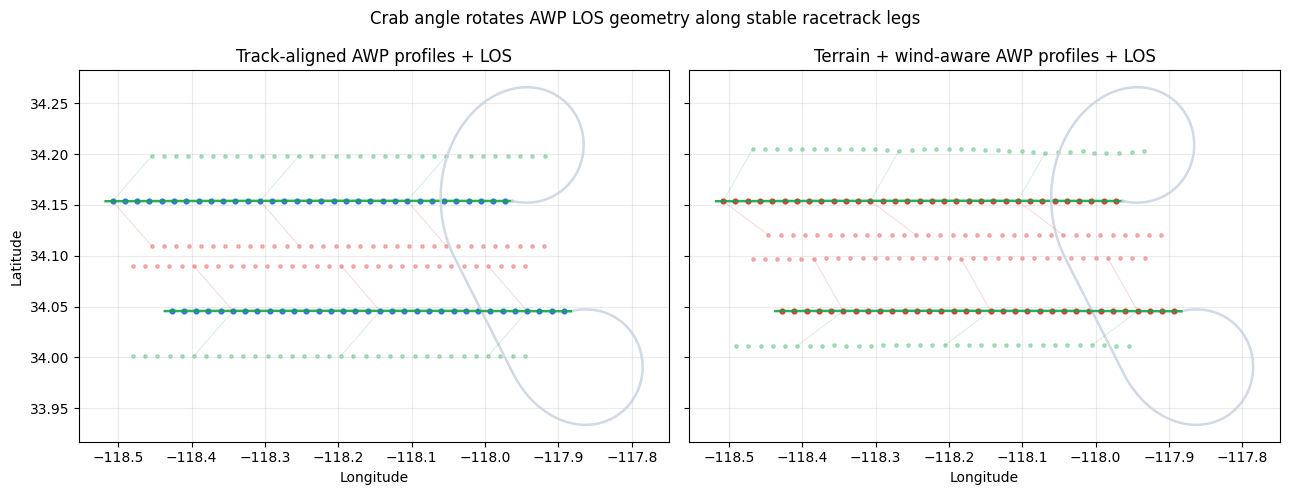

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)

for ax, profiles, title, color in [
    (axes[0], profiles_track, "Track-aligned AWP profiles + LOS", "#2563eb"),
    (axes[1], profiles_crabbed, "Terrain + wind-aware AWP profiles + LOS", "#dc2626"),
]:
    for _, row in windy_plan.iterrows():
        geom = row.geometry
        if getattr(geom, "geom_type", None) != "LineString":
            continue
        xs, ys = geom.xy
        line_color = "#16a34a" if row.get("segment_type") == "flight_line" else "#cbd5e1"
        ax.plot(xs, ys, color=line_color, linewidth=1.8, alpha=0.9)
    plot_awp_los(ax, profiles, every=12, alpha=0.18, linewidth=0.7)
    ax.scatter(profiles.geometry.x, profiles.geometry.y, s=12, color=color, alpha=0.85, label="Profile")
    ax.scatter(profiles["los1_lon"], profiles["los1_lat"], s=6, color="#16a34a", alpha=0.3)
    ax.scatter(profiles["los2_lon"], profiles["los2_lat"], s=6, color="#dc2626", alpha=0.3)
    ax.set_title(title)
    ax.set_xlabel("Longitude")
    ax.grid(alpha=0.25)

axes[0].set_ylabel("Latitude")
plt.suptitle("Crab angle rotates AWP LOS geometry along stable racetrack legs")
plt.tight_layout()
plt.show()

**What changed here?** The flight plan carries `planned_track`, `wind_corrected_heading`, and `crab_angle_deg` for each flight line. When `wind_aware=False`, AWP LOS geometry stays aligned with the ground track. When `wind_aware=True`, HyPlan rotates the platform heading and both LOS azimuths to match the crabbed aircraft heading, and `terrain_aware=True` then ray-traces those crabbed beams into the DEM. Drawing the LOS overlays makes the rotation easy to see between the two panels. That gives you plan-level AWP geometry that is both terrain-aware and wind-aware in the same way HyPlan already handles crab-aware swaths, while keeping the demo compact enough to run quickly in a notebook.

## Operational Takeaways

- **AWP is profile-driven, not swath-driven.** The primary design outputs are profile spacing, LOS intercept separation, and stable-leg availability.
- **Longer LOS dwell increases sensitivity but reduces horizontal detail.** HyPlan makes that tradeoff explicit in distance/time units.
- **Terrain-aware AWP planning changes both AGL and beam intercept geometry.** Over relief, DEM-backed ray tracing gives more realistic surface intercepts than a flat-earth AGL assumption.
- **Wind-aware AWP planning matters most when crosswinds create nontrivial crab angles.** In that case the aircraft nose, LOS azimuths, and ground-track azimuth are no longer the same.
- **Turns are the enemy of clean vector retrievals.** AWP planning works best when you can create long straight legs with minimal roll and altitude change.
- **Racetrack-style patterns are natural for repeated wind profiling.** They provide multiple stable legs while keeping the sortie geographically compact.

This notebook focuses on airborne AWP geometry. It does **not** attempt to model coherent Doppler retrieval physics, aerosol signal availability, or retrieval success probability, which should remain separate higher-fidelity analyses.


## References

Bedka, K., Marketon, J., Henderson, S., and Kavaya, M. (2024). "AWP: NASA's Aerosol Wind Profiler Coherent Doppler Wind Lidar." In Singh, U. N., Tzeremes, G., Refaat, T. F., and Ribes Pleguezuelo, P. (eds), *Space-based Lidar Remote Sensing Techniques and Emerging Technologies*, LIDAR 2023, Springer Aerospace Technology. https://doi.org/10.1007/978-3-031-53618-2_3

Bedka, K. (2025). *3-D Lidar Wind Airborne Profiling Using A Coherent-Detection Doppler Wind Lidar Designed For Space-Based Operation*. Final Project Report in response to the NOAA Broad Agency Announcement, "Measuring the Atmospheric Wind Profile (3D Winds): Call for Studies and Field Measurement Campaigns."
